In [6]:
import os
import sys
import math
import torch
import random
import numpy as np
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat, einsum

import training_engine  
import inference_engine
from rms_norm_file import RMSNorm


MODEL_CONFIGS = {
    "embed_dim"   : 2**5,   # 32
    "max_seq_len" : 2**6,   # 64
    "vocab_size"  : 2**11,  # 2048
   
    "batch_size"  : 2**4,   # 16
    "learning_rate" : 1e-3,

    "save_path" : "../models/level2_fixed_positional.pt",
    "loss_history" : "../models/level2_fixed_positional_loss_history.txt",
}



# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)


cuda


In [2]:
class Level2PositionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.vocab_size = MODEL_CONFIGS["vocab_size"]
        self.embed_dim = MODEL_CONFIGS["embed_dim"]
        self.max_seq_len = MODEL_CONFIGS["max_seq_len"]


        # Token Embedding lookup (learnable parameters)
        self.embed = nn.Parameter(torch.randn(self.vocab_size, self.embed_dim) * 0.02)

        self.rms_norm = RMSNorm(self.embed_dim)

        # Unembedding Projection matrix (learnable parameters)
        self.unembed = nn.Parameter(torch.randn(self.embed_dim, self.vocab_size) * 0.02)



        # ------------------------------------------------------------------
        # Fixed sinusoidal positional encodings (non-learnable)
        # ------------------------------------------------------------------

        # Pre-computing Fixed Sinusoidal Positional Encodings (not learnable parameters)
        pos_enc = torch.zeros(self.max_seq_len, self.embed_dim)
        position = torch.arange(0, self.max_seq_len, dtype=torch.float).unsqueeze(1) # Shape: (max_seq_len, 1)

        
        # Geometric progression division term: 10000^(2i/d_embed)
        # Operating in log-space for numerical stability
        div_term = torch.exp(torch.arange(0, self.embed_dim, step=2).float() *
                              (-math.log(10000.0) / self.embed_dim)
                            ) # Shape: (embed_dim/2)

        # Apply sine to even indices,
        pos_enc[:, 0::2] = torch.sin(position * div_term)
        # cosine to odd indices
        pos_enc[:, 1::2] = torch.cos(position * div_term)

        # Register as buffer: model state, non-learnable(gets no gradients)
        self.register_buffer('pos_enc', pos_enc)

  
        
    def forward(self, idx: torch.Tensor)-> torch.Tensor:

        batch_size, seq_len  = idx.shape

        # Assert to prevent sequence lengths exceeding pre-computed PE capacity
        assert seq_len <= self.max_seq_len, f"Sequence length {seq_len} exceeds maximum sequence length {self.max_seq_len}"

        # Token embedding lookup -> Shape: (batch_size, seq_len, embed_dim)
        x_token = self.embed[idx]

        # Positional encodings: (seq_len, embed_dim)
        x_pos = self.pos_enc[:seq_len]

        x_pos = rearrange(self.pos_enc[:seq_len], "seq_len embed_dim -> 1 seq_len embed_dim")
        x = x_token + x_pos  # PyTorch automatically broadcasts the batch dimension of 1 to batch_size

        x_norm = self.rms_norm(x)

        # Unembed projection
        logits = einsum(x_norm, self.unembed, 
                        "batch_size seq_len embed_dim, embed_dim vocab_size"
                        " -> "
                        "batch_size seq_len vocab_size")
        
        return logits


Step 0000 | Batch Loss: 7.6387 nats
Step 0005 | Batch Loss: 7.5896 nats
Step 0010 | Batch Loss: 7.5433 nats
Step 0015 | Batch Loss: 7.5064 nats
Step 0020 | Batch Loss: 7.4702 nats
Step 0025 | Batch Loss: 7.4300 nats
Step 0030 | Batch Loss: 7.4103 nats
Step 0035 | Batch Loss: 7.3748 nats
Step 0040 | Batch Loss: 7.3525 nats
Step 0045 | Batch Loss: 7.3404 nats
Step 0050 | Batch Loss: 7.3067 nats
Step 0055 | Batch Loss: 7.2760 nats
Step 0060 | Batch Loss: 7.2473 nats
Step 0065 | Batch Loss: 7.2511 nats
Step 0070 | Batch Loss: 7.2068 nats
Step 0075 | Batch Loss: 7.1661 nats
Step 0080 | Batch Loss: 7.2005 nats
Step 0085 | Batch Loss: 7.1476 nats
Step 0090 | Batch Loss: 7.1581 nats
Step 0095 | Batch Loss: 7.1153 nats
Step 0099 | Batch Loss: 7.1223 nats

Saving model weights to: ../models/level2_fixed_positional.pt
Loss history successfully saved to ../models/level2_fixed_positional_loss_history.txt
Loaded 100 steps from ../models/level2_fixed_positional_loss_history.txt


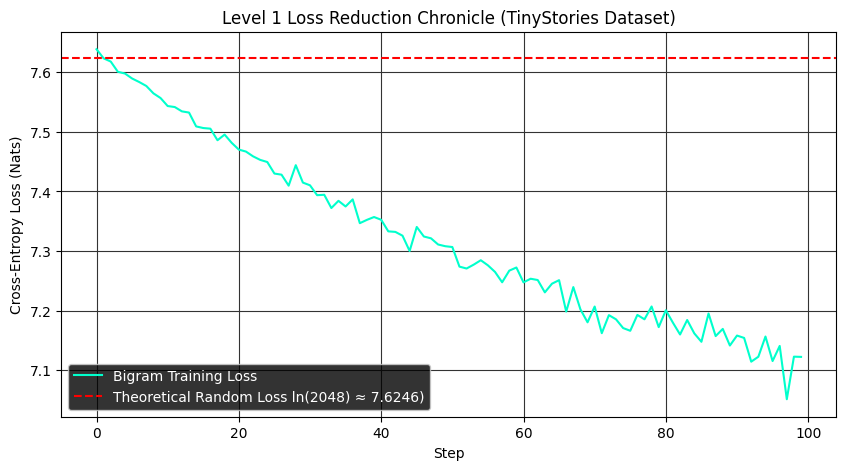

In [3]:
model = Level2PositionModel()
configs = MODEL_CONFIGS

training_engine.train_and_save_model(model, configs, device, 100)
training_engine.plot_loss_history(configs)


In [4]:
prompt = "write a story about"
model_scaffold = Level2PositionModel()

samples = inference_engine.simple_inference(model_scaffold, MODEL_CONFIGS, 200, prompt, device, temperature=0.5)
print(samples)


[INFO] Starting inference with prompt: write a story about
[INFO] Loaded weights from ../models/level2_fixed_positional.pt  (131,104 parameters)
full_seq before 1/200:
[1430, 787, 138, 379, 68, 264, 52, 395]
context_window_limited_seq_tensor.shape-> 
torch.Size([1, 8])
[INFO] Step 1/200: Context window length: 8
model_output_logits.shape->
torch.Size([1, 8, 2048])
last_token_logits.shape->
torch.Size([2048])
probabilities.shape-> 
torch.Size([2048])
probabilities-> 
tensor([7.0370e-03, 3.7389e-03, 8.9712e-05,  ..., 7.2858e-05, 7.5905e-05,
        1.3439e-04], device='cuda:0')
next_token_tensor.shape-> 
torch.Size([1])
next_token_tensor-> 
tensor([54], device='cuda:0')
full_seq.append after append: 
[1430, 787, 138, 379, 68, 264, 52, 395, 54]
--------------------------------------------------------------------------------
full_seq before 2/200:
[1430, 787, 138, 379, 68, 264, 52, 395, 54]
context_window_limited_seq_tensor.shape-> 
torch.Size([1, 9])
[INFO] Step 2/200: Context window leng

In [5]:
training_engine.inspect_weight_file(configs["save_path"], False)

Loaded state_dict from ..\models\level2_fixed_positional.pt
Number of parameter tensors: 4
Number of parameters: 133,152

PARAMETER SUMMARY
embed: shape=(2048, 32), dtype=torch.float32, requires_grad=False, numel=65,536
unembed: shape=(32, 2048), dtype=torch.float32, requires_grad=False, numel=65,536
pos_enc: shape=(64, 32), dtype=torch.float32, requires_grad=False, numel=2,048
rms_norm.weight: shape=(32,), dtype=torch.float32, requires_grad=False, numel=32
